# Relative Dose Plot: MBO CCB vs MBO AIC-144

This notebook compares **MBO foil depth-dose profiles** for **CCB** and **AIC-144**.

Each foil profile is aligned to the **distal 90% falloff point** from its corresponding
**MC wedge simulation** (CCB-to-CCB MC and AIC-144-to-AIC-144 MC).
This preserves the MC-predicted range difference between beams.

Each profile is rescaled so its maximum equals **1.0**.

Color convention:
- **CCB** in **green**
- **AIC-144** in **red**

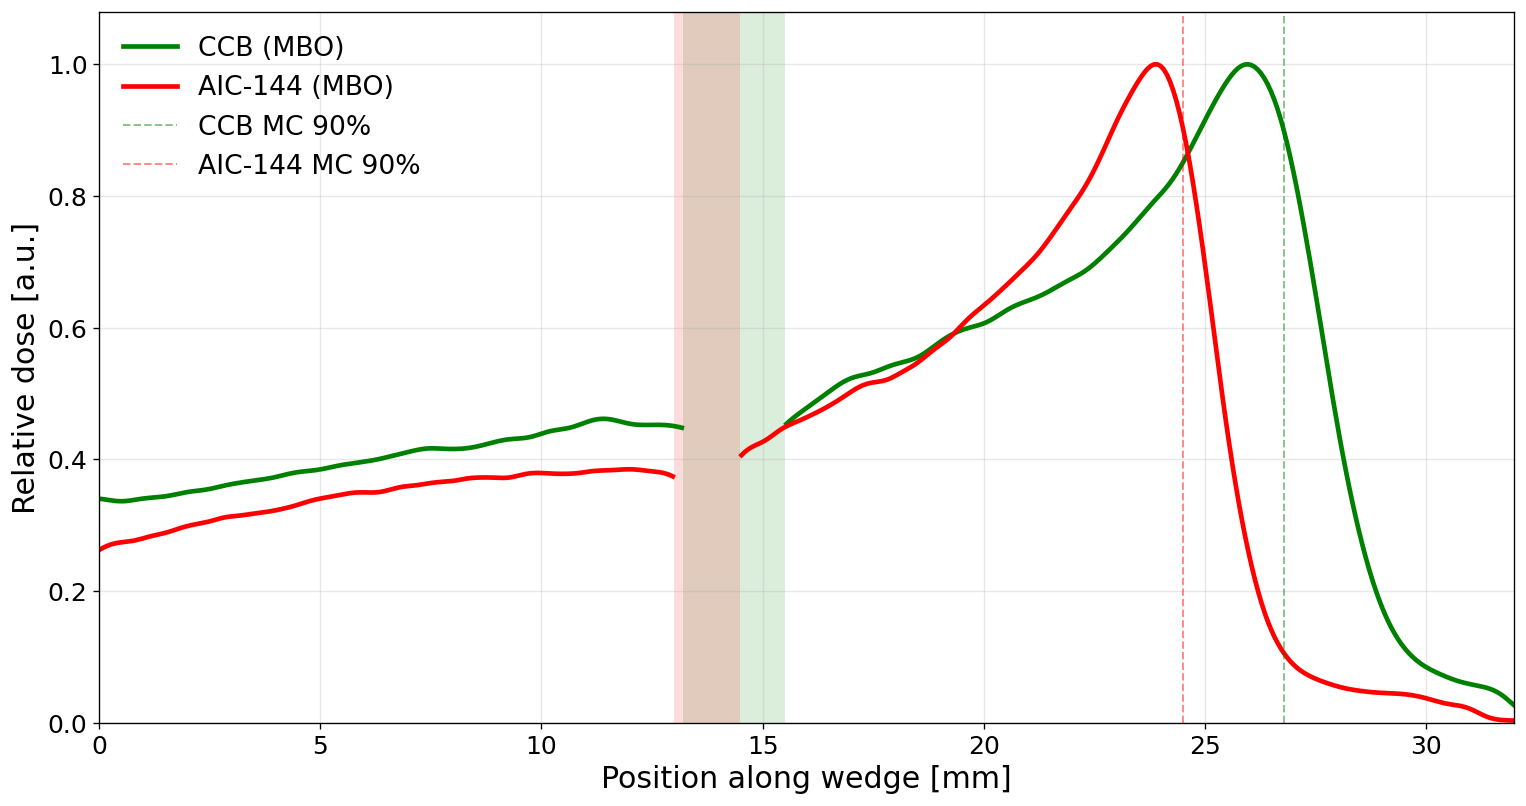

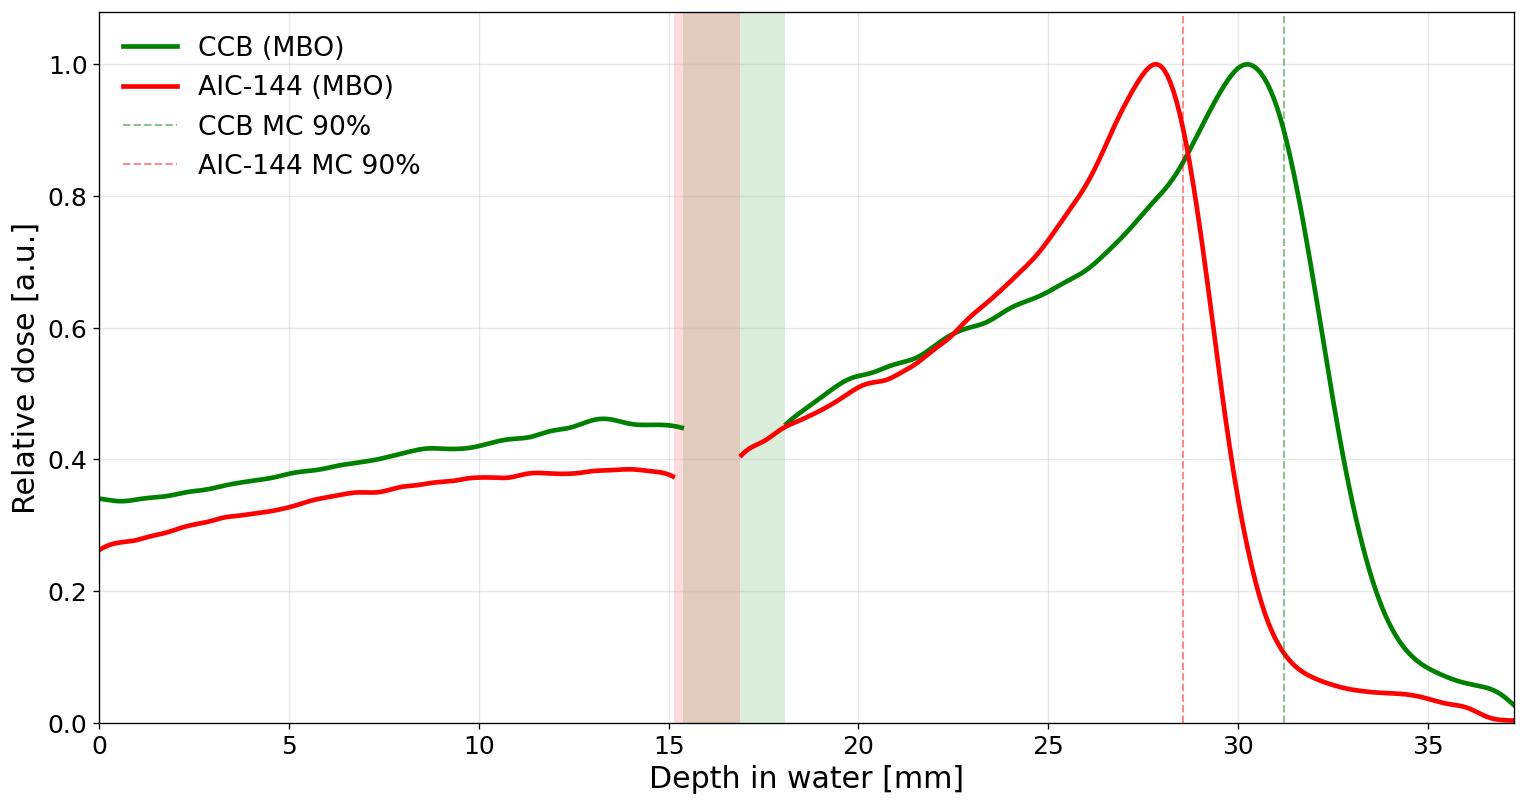

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repository root from current working directory.
repo_root = Path.cwd()
if not (repo_root / "notebooks" / "pub_something_2026").exists():
    for parent in repo_root.parents:
        if (parent / "notebooks" / "pub_something_2026").exists():
            repo_root = parent
            break

base_root = repo_root / "notebooks" / "pub_something_2026"
foil_root = base_root / "mbo_foils"
mc_root = base_root / "mc"
# Prefer fresh MBO profiles produced by the CLI pipeline; fall back
# to the notebook-local cached CSVs in `mbo_foils/`.
mbo_pipeline_dir = repo_root / "output" / "pub2026" / "mbo" / "data"

def _pick(name):
    fresh = mbo_pipeline_dir / name
    return fresh if fresh.exists() else foil_root / name

ccb_file = _pick("mbo_profile_ccb.csv")
aic_file = _pick("mbo_profile_aic144.csv")
mc_ccb_file = mc_root / "mc_ccb_big.csv"
mc_aic_file = mc_root / "mc_aic144_big.csv"

# Adjustable vertical bump marker bands [mm].
CCB_BUMP_MIN_MM = 13.2
CCB_BUMP_MAX_MM = 15.5
AIC_BUMP_MIN_MM = 13.0
AIC_BUMP_MAX_MM = 14.5
BUMP_BAND_ALPHA = 0.14
BUMP_BAND_YMAX = 0.28  # Draw near the bottom to mark downward bumps.

WATER_EQ_FACTOR = 1.165

for f in (ccb_file, aic_file, mc_ccb_file, mc_aic_file):
    if not f.exists():
        raise FileNotFoundError(f"Missing input file: {f}")

ccb = pd.read_csv(ccb_file)
aic = pd.read_csv(aic_file)
mc_ccb = pd.read_csv(mc_ccb_file).rename(columns={"depth": "x_mm", "dose": "dose_Gy"})
mc_aic = pd.read_csv(mc_aic_file).rename(columns={"depth": "x_mm", "dose": "dose_Gy"})

def prepare_profile(df):
    profile = df[["x_mm", "dose_Gy"]].copy().sort_values("x_mm").reset_index(drop=True)
    profile["relative_dose"] = profile["dose_Gy"] / profile["dose_Gy"].max()
    return profile

def distal_falloff_point(profile, level=0.9):
    x = profile["x_mm"].to_numpy()
    y = profile["relative_dose"].to_numpy()

    peak_idx = y.argmax()
    for idx in range(peak_idx + 1, len(y)):
        if y[idx] <= level:
            x0, x1 = x[idx - 1], x[idx]
            y0, y1 = y[idx - 1], y[idx]
            if y1 == y0:
                return x1
            fraction = (level - y0) / (y1 - y0)
            return x0 + fraction * (x1 - x0)

    raise ValueError(f"Could not find distal {level:.0%} falloff point.")

ccb = prepare_profile(ccb)
aic = prepare_profile(aic)
mc_ccb = prepare_profile(mc_ccb)
mc_aic = prepare_profile(mc_aic)

foil_ccb_range_90 = distal_falloff_point(ccb, level=0.9)
foil_aic_range_90 = distal_falloff_point(aic, level=0.9)
mc_ccb_range_90 = distal_falloff_point(mc_ccb, level=0.9)
mc_aic_range_90 = distal_falloff_point(mc_aic, level=0.9)

ccb_shift = mc_ccb_range_90 - foil_ccb_range_90
aic_shift = mc_aic_range_90 - foil_aic_range_90

ccb["x_aligned_mm"] = ccb["x_mm"] + ccb_shift
aic["x_aligned_mm"] = aic["x_mm"] + aic_shift

# Do not interpolate across bump regions: mask those samples directly.
ccb_plot = ccb.copy()
aic_plot = aic.copy()
ccb_strip_mask = (ccb_plot["x_aligned_mm"] >= CCB_BUMP_MIN_MM) & (ccb_plot["x_aligned_mm"] <= CCB_BUMP_MAX_MM)
aic_strip_mask = (aic_plot["x_aligned_mm"] >= AIC_BUMP_MIN_MM) & (aic_plot["x_aligned_mm"] <= AIC_BUMP_MAX_MM)
ccb_plot.loc[ccb_strip_mask, "relative_dose"] = float("nan")
aic_plot.loc[aic_strip_mask, "relative_dose"] = float("nan")

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16,
})

# Plot 1: position behind wedge [mm]
fig, ax = plt.subplots(figsize=(13, 7), dpi=120)

ax.axvspan(CCB_BUMP_MIN_MM, CCB_BUMP_MAX_MM, color="green", alpha=BUMP_BAND_ALPHA, linewidth=0)
ax.axvspan(AIC_BUMP_MIN_MM, AIC_BUMP_MAX_MM, color="red", alpha=BUMP_BAND_ALPHA, linewidth=0)

ax.plot(ccb_plot["x_aligned_mm"], ccb_plot["relative_dose"], color="green", linewidth=2.8, label="CCB (MBO)")
ax.plot(aic_plot["x_aligned_mm"], aic_plot["relative_dose"], color="red", linewidth=2.8, label="AIC-144 (MBO)")

ax.axvline(mc_ccb_range_90, color="green", linestyle="--", linewidth=1.2, alpha=0.45, label="CCB MC 90%")
ax.axvline(mc_aic_range_90, color="red", linestyle="--", linewidth=1.2, alpha=0.45, label="AIC-144 MC 90%")

ax.set_xlabel("Position along wedge [mm]")
ax.set_ylabel("Relative dose [a.u.]")
ax.set_xlim(0, 32)
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# Plot 2: water-equivalent depth [mm]
ccb_plot["x_water_mm"] = ccb_plot["x_aligned_mm"] * WATER_EQ_FACTOR
aic_plot["x_water_mm"] = aic_plot["x_aligned_mm"] * WATER_EQ_FACTOR
mc_ccb_range_90_water = mc_ccb_range_90 * WATER_EQ_FACTOR
mc_aic_range_90_water = mc_aic_range_90 * WATER_EQ_FACTOR

fig, ax = plt.subplots(figsize=(13, 7), dpi=120)

ax.axvspan(CCB_BUMP_MIN_MM * WATER_EQ_FACTOR, CCB_BUMP_MAX_MM * WATER_EQ_FACTOR, color="green", alpha=BUMP_BAND_ALPHA, linewidth=0)
ax.axvspan(AIC_BUMP_MIN_MM * WATER_EQ_FACTOR, AIC_BUMP_MAX_MM * WATER_EQ_FACTOR, color="red", alpha=BUMP_BAND_ALPHA, linewidth=0)

ax.plot(ccb_plot["x_water_mm"], ccb_plot["relative_dose"], color="green", linewidth=2.8, label="CCB (MBO)")
ax.plot(aic_plot["x_water_mm"], aic_plot["relative_dose"], color="red", linewidth=2.8, label="AIC-144 (MBO)")

ax.axvline(mc_ccb_range_90_water, color="green", linestyle="--", linewidth=1.2, alpha=0.45, label="CCB MC 90%")
ax.axvline(mc_aic_range_90_water, color="red", linestyle="--", linewidth=1.2, alpha=0.45, label="AIC-144 MC 90%")

ax.set_xlabel("Depth in water [mm]")
ax.set_ylabel("Relative dose [a.u.]")
ax.set_xlim(0, 32 * WATER_EQ_FACTOR)
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()
